In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np

In [3]:
df = pd.read_csv('../../data/hyper.csv')

In [4]:
df.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age,bmi,bp_category
0,M,168,62.0,110,80,1,1,0,0,1,50,21.967120,Hypertension Stage 1
1,F,156,85.0,140,90,3,1,0,0,1,55,34.927679,Hypertension Stage 2
2,F,165,64.0,130,70,3,1,0,0,0,51,23.507805,Hypertension Stage 1
3,M,169,82.0,150,100,1,1,0,0,1,48,28.710479,Hypertension Stage 2
4,F,156,56.0,100,60,1,1,0,0,0,47,23.011177,Normal


## check the distribution of the target 

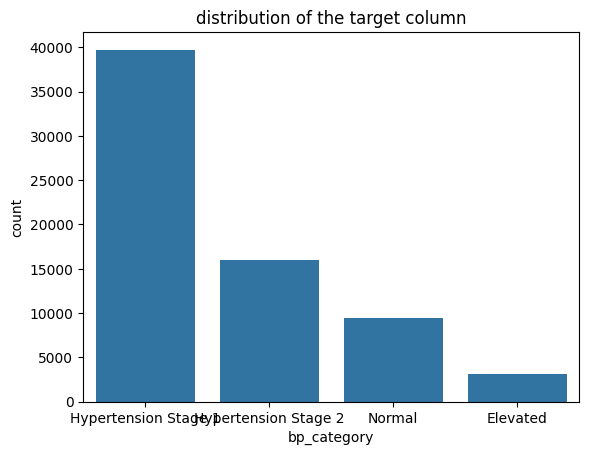

In [6]:
sns.barplot(df['bp_category'].value_counts())
plt.title("distribution of the target column")
plt.show()


In [9]:
num_col = df.select_dtypes(exclude='object').columns.drop(['cholesterol','gluc','smoke', 'alco','active']).to_list()
num_col

['height', 'weight', 'ap_hi', 'ap_lo', 'age', 'bmi']

In [15]:
cat_cols = df[['gender', 'cholesterol','gluc','smoke', 'alco','active']].columns.to_list()
cat_cols

['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

### check distribution of numeric column

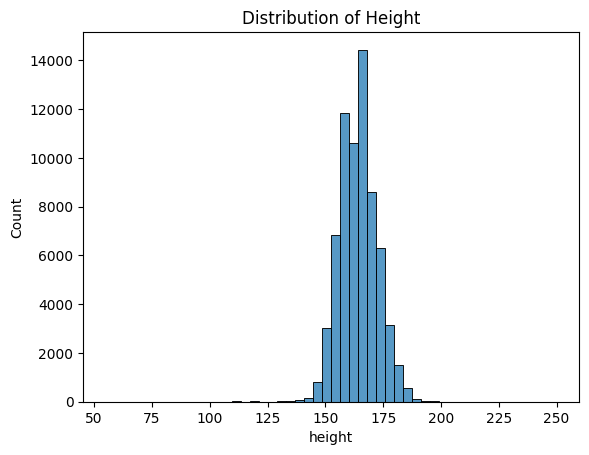

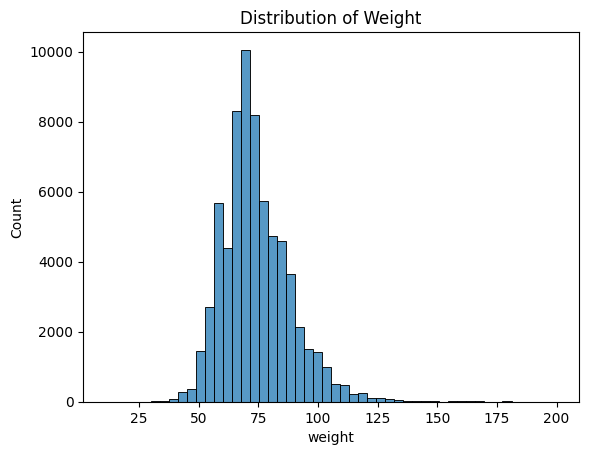

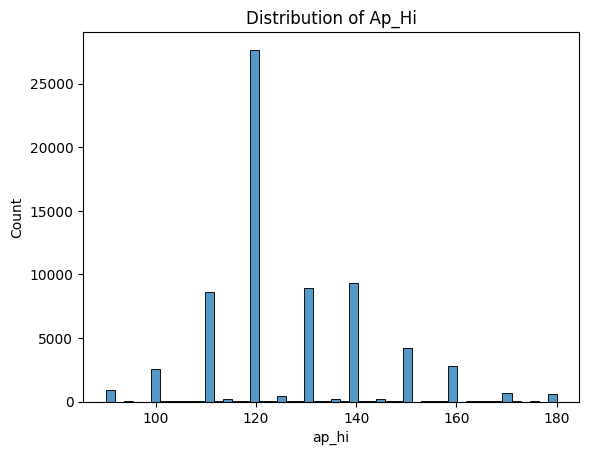

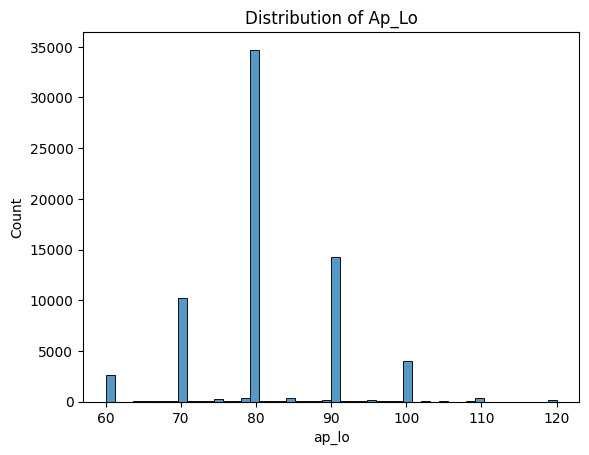

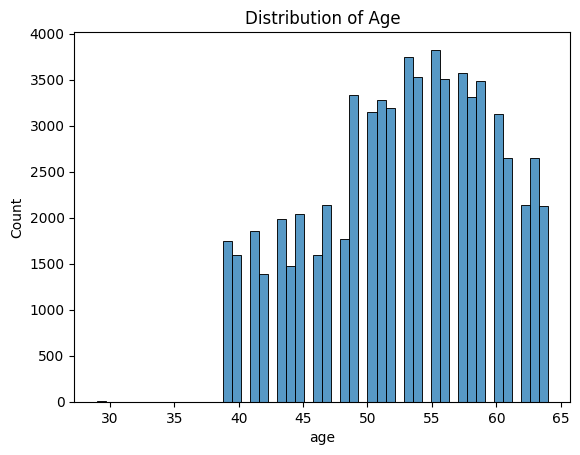

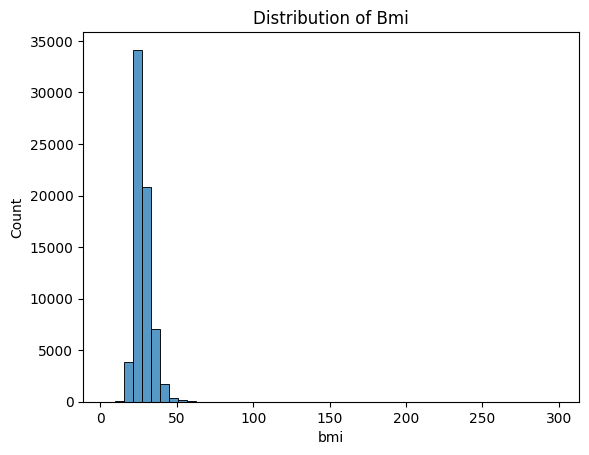

In [18]:
for col in num_col:
    sns.histplot(df[col], bins=50)
    plt.title(f"Distribution of {col.title()}")
    plt.show()

### Categorical columns

Gender
gender
F    44427
M    23778
Name: count, dtype: int64


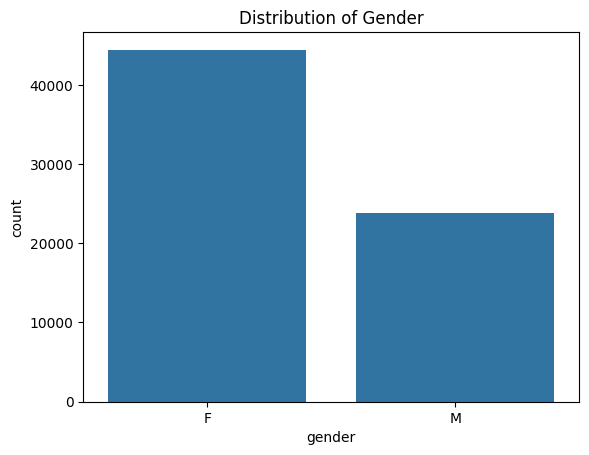

Cholesterol
cholesterol
1    51222
2     9191
3     7792
Name: count, dtype: int64


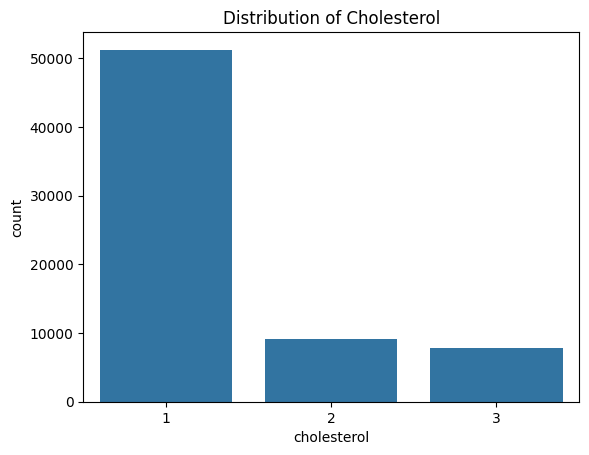

Gluc
gluc
1    58027
3     5180
2     4998
Name: count, dtype: int64


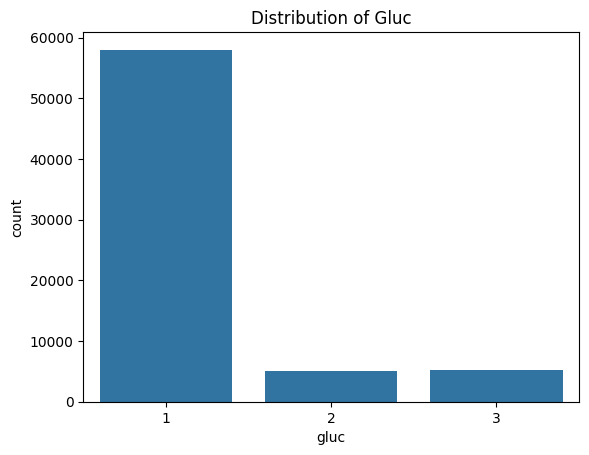

Smoke
smoke
0    62226
1     5979
Name: count, dtype: int64


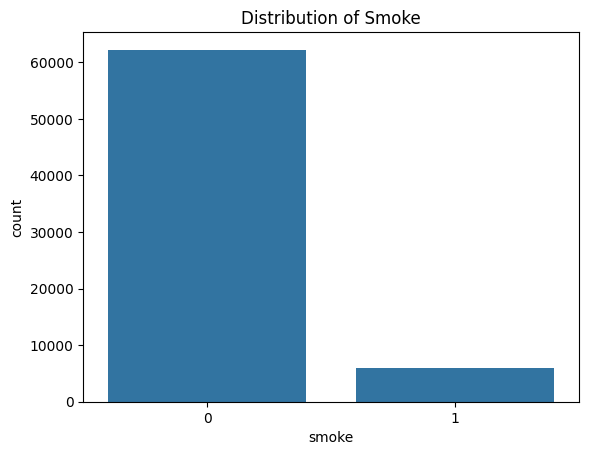

Alco
alco
0    64581
1     3624
Name: count, dtype: int64


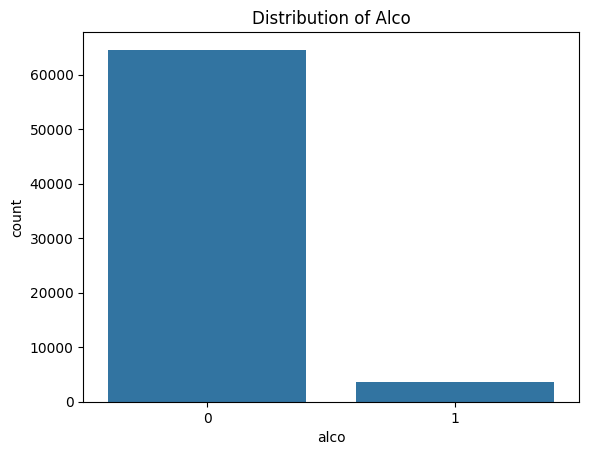

Active
active
1    54806
0    13399
Name: count, dtype: int64


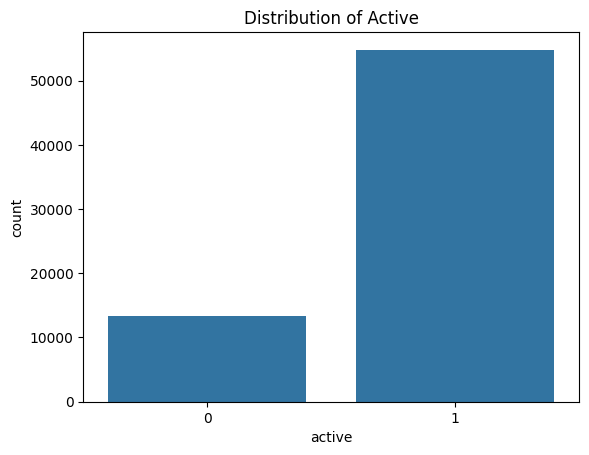

In [19]:
for col in cat_cols:
    cat_counts = df[col].value_counts()
    print(f"{col.title()}")
    print("==============")
    print(cat_counts)
    sns.barplot(cat_counts)
    plt.title(f"Distribution of {col.title()}")
    plt.show()

### Bivariate Analysis

In [22]:
df['bp_enconded'] = df['bp_category'].astype('category').cat.codes

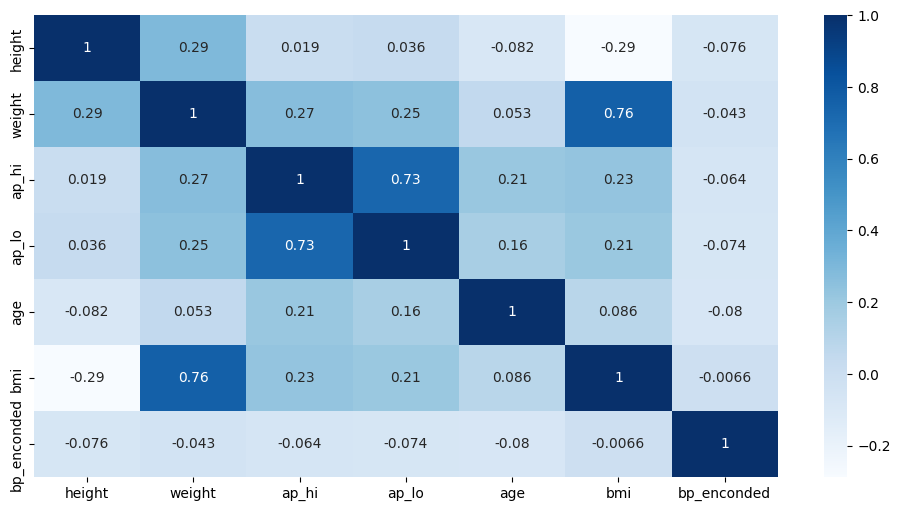

In [23]:
corr = df[num_col + ["bp_enconded"]].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, cmap="Blues");

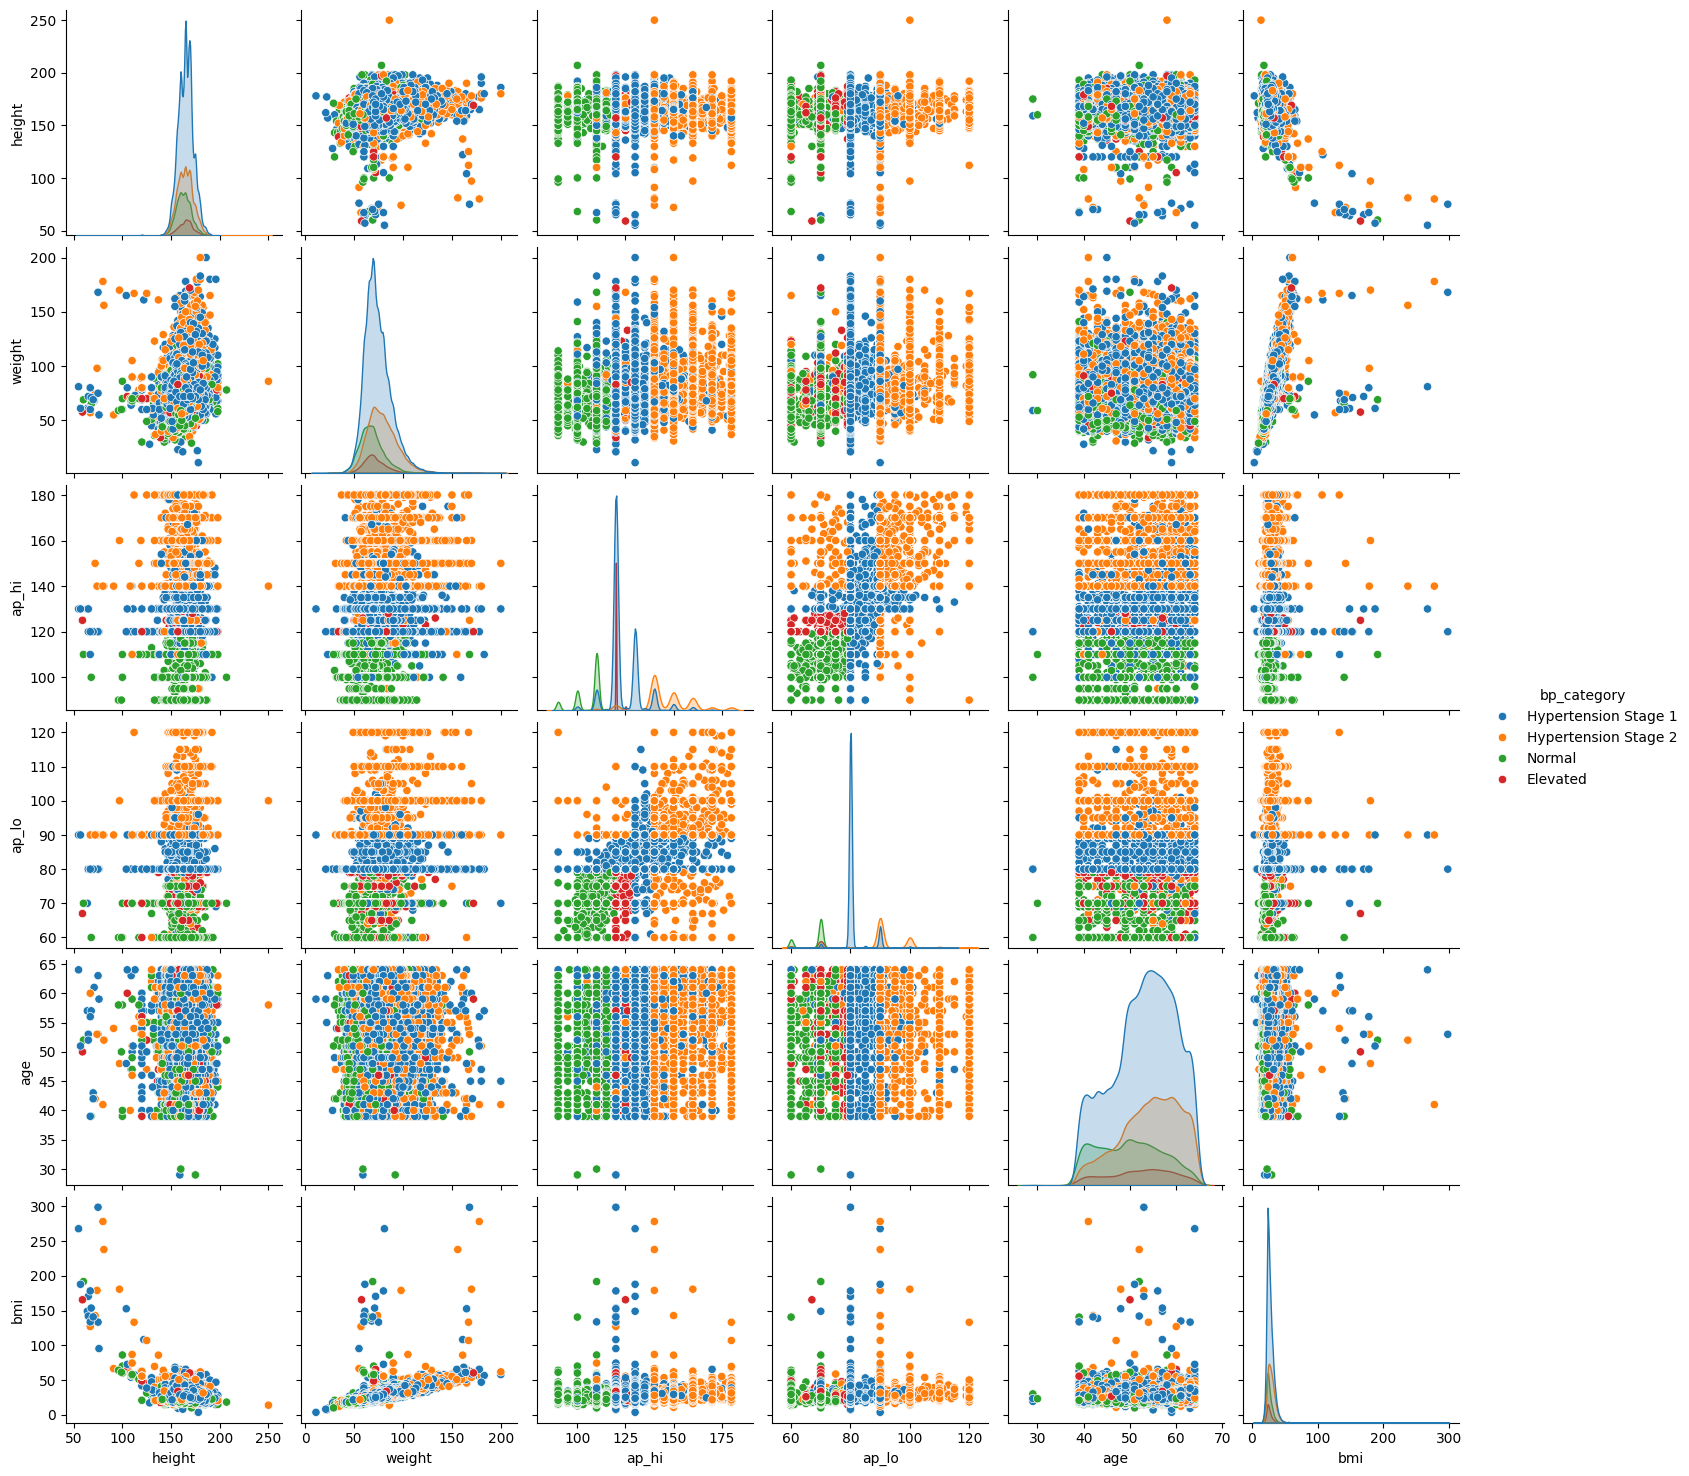

In [35]:
sns.pairplot(df[num_col+["bp_category"]], hue="bp_category")

### Exploring average values by bp category

bp_category
Elevated                164.750726
Hypertension Stage 1    164.769082
Hypertension Stage 2    164.254628
Normal                  162.776043
Name: height, dtype: float64


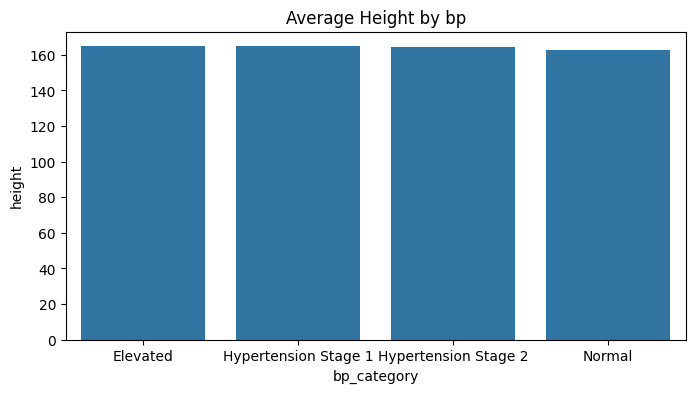

bp_category
Elevated                70.951725
Hypertension Stage 1    73.913973
Hypertension Stage 2    78.934857
Normal                  67.744600
Name: weight, dtype: float64


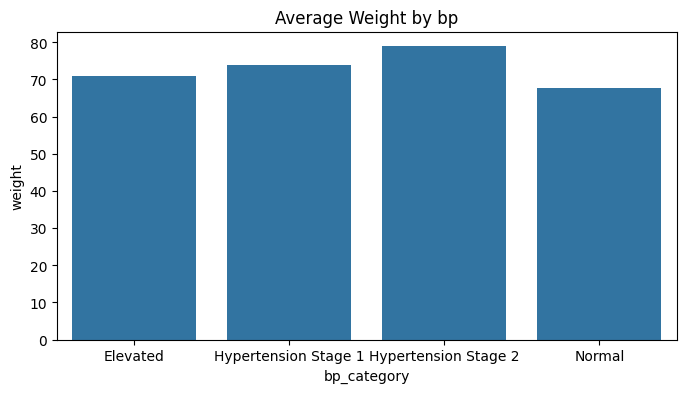

bp_category
Elevated                120.203483
Hypertension Stage 1    123.914264
Hypertension Stage 2    146.102466
Normal                  105.842200
Name: ap_hi, dtype: float64


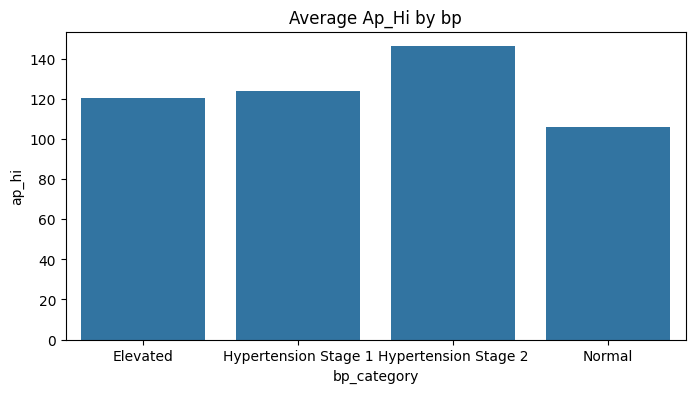

bp_category
Elevated                69.385360
Hypertension Stage 1    80.856453
Hypertension Stage 2    92.495137
Normal                  67.888181
Name: ap_lo, dtype: float64


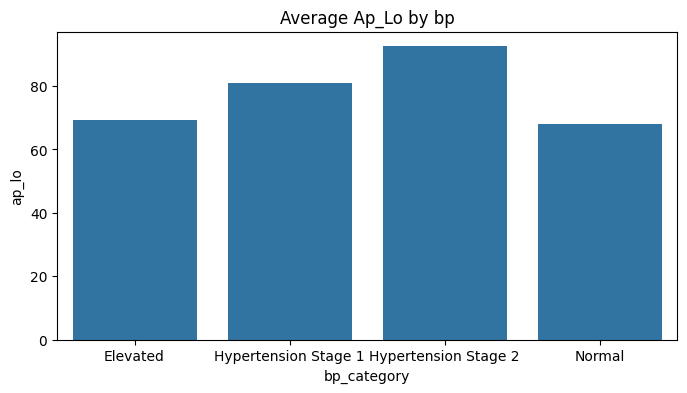

bp_category
Elevated                52.123509
Hypertension Stage 1    52.981660
Hypertension Stage 2    54.256071
Normal                  49.962939
Name: age, dtype: float64


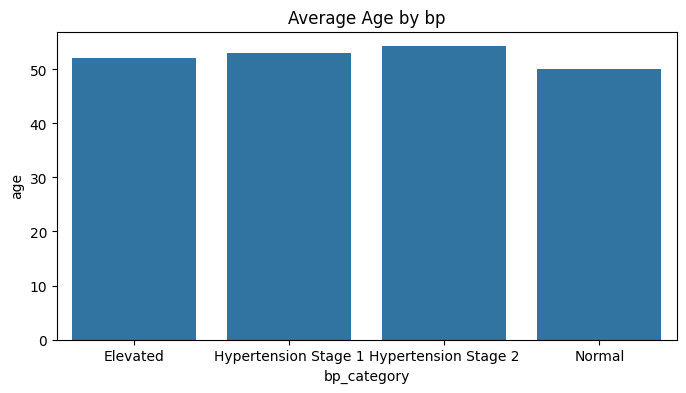

bp_category
Elevated                26.237628
Hypertension Stage 1    27.315562
Hypertension Stage 2    29.359921
Normal                  25.622703
Name: bmi, dtype: float64


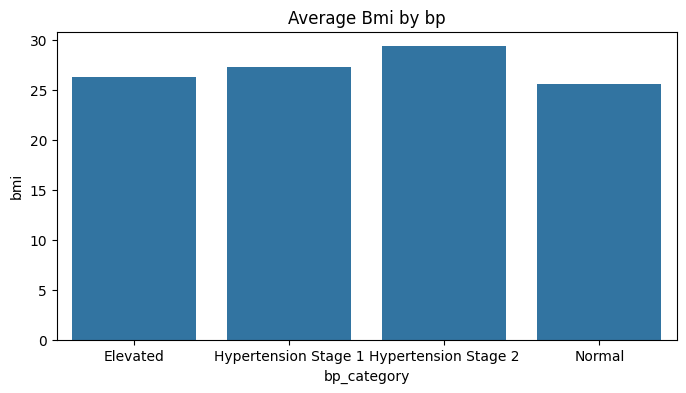

In [44]:
for col in num_col:
    group_average = df.groupby("bp_category")[col].mean()
    print(group_average)
    plt.figure(figsize=(8,4))
    sns.barplot(group_average)
    plt.title(f"Average {col.title()} by bp")
    plt.show()

### Exploring Hypertension by category

gender
F    1.494654
M    1.407688
Name: bp_enconded, dtype: float64


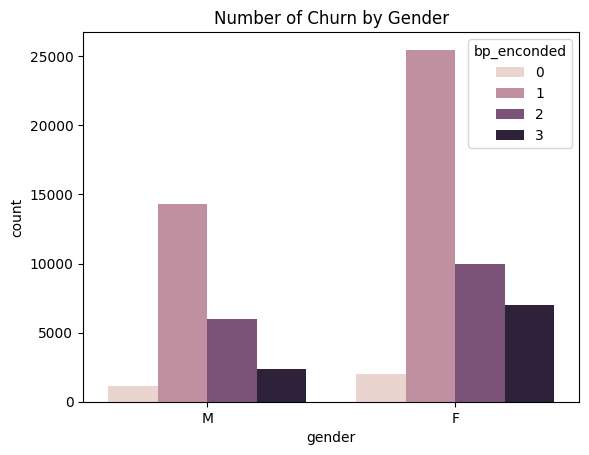

cholesterol
1    1.446546
2    1.579262
3    1.445714
Name: bp_enconded, dtype: float64


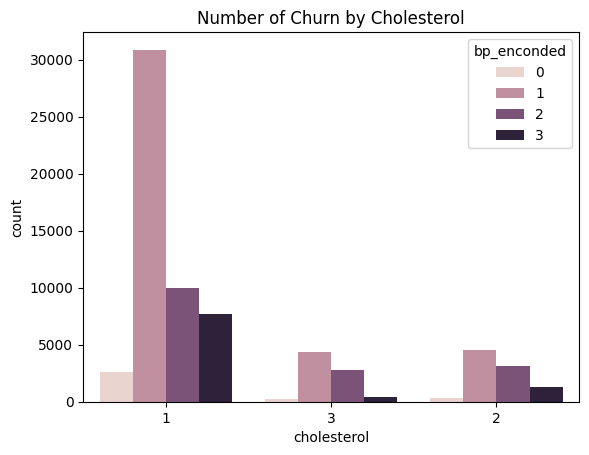

gluc
1    1.461320
2    1.550020
3    1.415444
Name: bp_enconded, dtype: float64


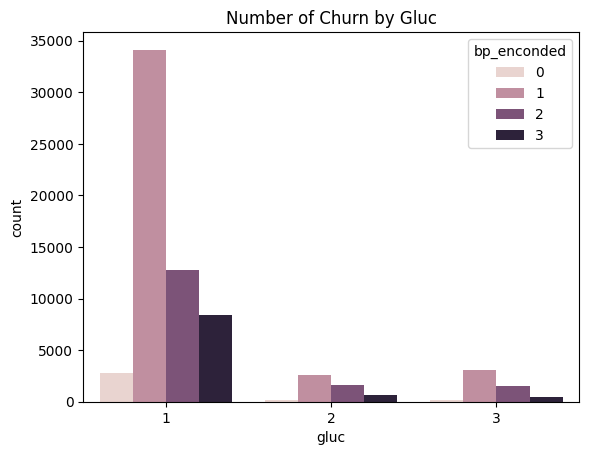

smoke
0    1.464693
1    1.460612
Name: bp_enconded, dtype: float64


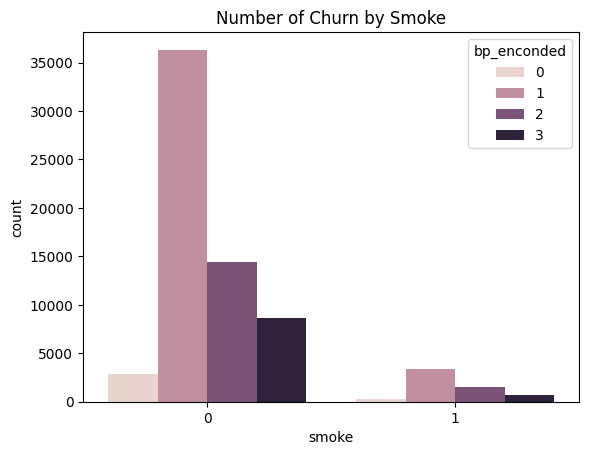

alco
0    1.463790
1    1.474062
Name: bp_enconded, dtype: float64


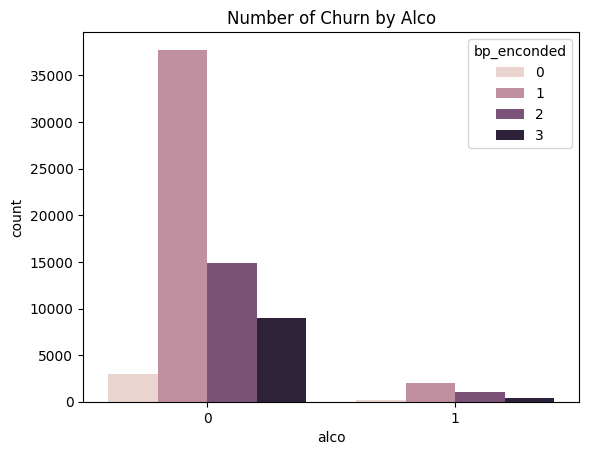

active
0    1.439809
1    1.470332
Name: bp_enconded, dtype: float64


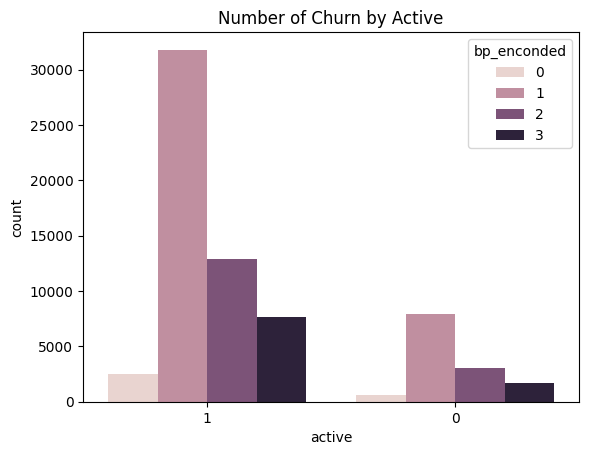

In [47]:
for col in cat_cols:
    group_bp_rate = df.groupby(col)["bp_enconded"].mean()
    print(group_bp_rate)
    sns.countplot(x=df[col].astype(str), hue=df["bp_enconded"])
    plt.title(f"Number of Churn by {col.title()}")
    plt.show()

## Check mutual information score between categorical features and target

In [48]:
from sklearn.metrics import mutual_info_score

In [49]:
df[cat_cols].apply(
    lambda feature: mutual_info_score(df["bp_category"], feature)
).sort_values(ascending=False)

cholesterol    0.015110
gluc           0.003991
gender         0.003349
alco           0.000459
smoke          0.000212
active         0.000122
dtype: float64